# Session 11 — Image Segmentation: Hands-On Lab

**Phase 3 · Core CV Tasks · Week 8**

In this notebook we put the theory from the slides into practice:

1. **Visualise** what "segmentation" actually means at the pixel level
2. **Build a tiny U-Net** from scratch in PyTorch
3. **Train it** on a synthetic cell-microscopy dataset
4. **Evaluate** with Dice and IoU metrics
5. **Run YOLOv8-seg** for *instance* segmentation on a sample image

By the end of this lab you'll have **trained a real semantic-segmentation model**
and produced **real instance masks** with a single line of code.

## 1. Setup

We need PyTorch, NumPy, matplotlib, and Ultralytics (for YOLOv8-seg).
Run the install cell below if you don't already have them.

In [1]:
# Uncomment if you need to install dependencies
# !pip install -q torch torchvision matplotlib numpy ultralytics

import os, math, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch :', torch.__version__)
print('Device  :', DEVICE)

PyTorch : 2.6.0+cu124
Device  : cuda


## 2. What does "segmentation" actually look like?

Before we train anything, let's get an intuition for the three things that
matter in segmentation: the **input image**, the **mask**, and the **overlay**.

We'll generate a synthetic 2-D scene with three classes — *background*, *square*, *circle* —
so we can see the per-pixel labels with our own eyes.

In [2]:
def toy_scene(size=128):
    """Return a toy RGB image and its per-pixel class mask (0=bg, 1=square, 2=circle)."""
    img = np.full((size, size, 3), 230, dtype=np.uint8)  # near-white bg
    mask = np.zeros((size, size), dtype=np.int64)

    # A teal square
    sq = slice(20, 70)
    img[sq, sq] = (13, 148, 136)
    mask[sq, sq] = 1

    # A coral circle
    yy, xx = np.mgrid[0:size, 0:size]
    circle = (xx - 90) ** 2 + (yy - 80) ** 2 <= 28 ** 2
    img[circle] = (225, 29, 72)
    mask[circle] = 2

    return img, mask

img, mask = toy_scene()
print('image shape :', img.shape, ' dtype:', img.dtype)
print('mask shape  :', mask.shape, ' unique classes:', np.unique(mask))

image shape : (128, 128, 3)  dtype: uint8
mask shape  : (128, 128)  unique classes: [0 1 2]


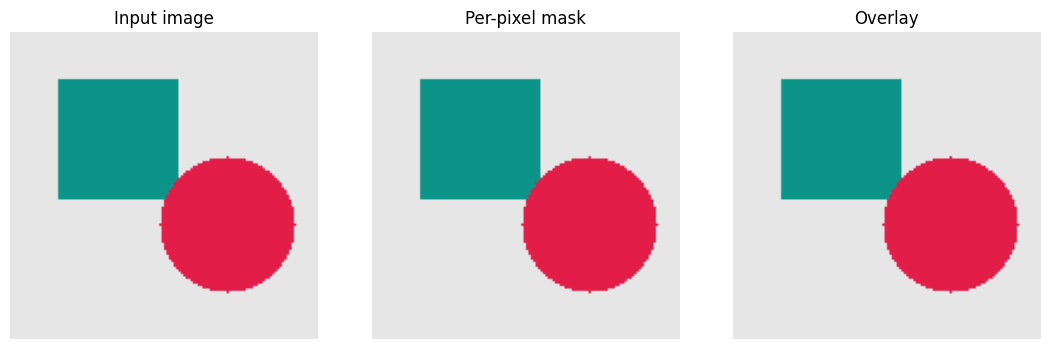

In [3]:
# Visualise: image | mask (false-colour) | overlay
PALETTE = np.array([[230,230,230], [13,148,136], [225,29,72]], dtype=np.uint8)

def color_mask(m):
    return PALETTE[m]

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
ax[0].imshow(img); ax[0].set_title('Input image'); ax[0].axis('off')
ax[1].imshow(color_mask(mask)); ax[1].set_title('Per-pixel mask'); ax[1].axis('off')
ax[2].imshow((0.5*img + 0.5*color_mask(mask)).astype(np.uint8))
ax[2].set_title('Overlay'); ax[2].axis('off')
plt.tight_layout(); plt.show()

**Takeaway:** segmentation is just *classification at every pixel*. Every pixel
in the mask is an integer class ID — here `0`, `1`, or `2`.

## 3. A synthetic cell-microscopy dataset

U-Net was originally invented for **biomedical** segmentation, so we'll mimic that
setting: blobs of "cells" on a dark background. The task is **binary segmentation** —
for each pixel, decide *cell* (`1`) or *background* (`0`).

We generate the data on-the-fly so the notebook is self-contained.

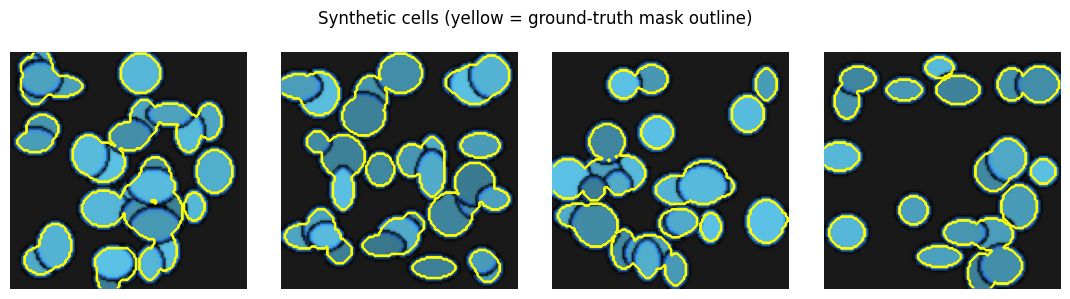

In [4]:
from PIL import Image, ImageDraw, ImageFilter

def make_cell_image(size=128, n_cells=None, rng=None):
    """Generate one (image, mask) pair of microscopy-like cells."""
    rng = rng or np.random.default_rng()
    n_cells = n_cells or rng.integers(15, 35)

    img = Image.new('RGB', (size, size), (25, 25, 25))
    msk = Image.new('L',  (size, size), 0)
    d_img, d_msk = ImageDraw.Draw(img), ImageDraw.Draw(msk)

    for _ in range(n_cells):
        cx, cy = rng.integers(8, size - 8, size=2)
        rx, ry = rng.integers(5, 12, size=2)
        bright = int(rng.integers(140, 230))
        # outer glow (gives soft edges)
        for k in range(3, 0, -1):
            d_img.ellipse([cx-rx-k, cy-ry-k, cx+rx+k, cy+ry+k],
                          fill=(int(bright*0.15*(3-k)),
                                int(bright*0.40*(3-k)),
                                int(bright*0.70*(3-k))))
        # cell body
        d_img.ellipse([cx-rx, cy-ry, cx+rx, cy+ry],
                      fill=(int(bright*0.4), int(bright*0.85), bright))
        d_msk.ellipse([cx-rx, cy-ry, cx+rx, cy+ry], fill=255)

    img = img.filter(ImageFilter.GaussianBlur(0.5))
    return np.array(img), (np.array(msk) > 0).astype(np.float32)

# Quick peek
rng = np.random.default_rng(0)
fig, ax = plt.subplots(1, 4, figsize=(11, 3))
for i in range(4):
    im, mk = make_cell_image(rng=rng)
    ax[i].imshow(im)
    ax[i].contour(mk, colors='yellow', linewidths=0.6)
    ax[i].axis('off')
plt.suptitle('Synthetic cells (yellow = ground-truth mask outline)')
plt.tight_layout(); plt.show()

### A PyTorch `Dataset`

We wrap the generator in a standard `Dataset` so the `DataLoader` can batch it.
Note: every call to `__getitem__` generates a *fresh* random scene — this acts
as infinite data augmentation.

In [5]:
class CellsDataset(Dataset):
    def __init__(self, n_samples=400, size=128, seed=0):
        self.n = n_samples
        self.size = size
        # one independent rng per worker, seeded by index in __getitem__
        self.seed = seed

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        rng = np.random.default_rng(self.seed * 10_000 + idx)
        im, mk = make_cell_image(self.size, rng=rng)
        # → tensors (C,H,W) in [0,1]
        x = torch.from_numpy(im).permute(2, 0, 1).float() / 255.0
        y = torch.from_numpy(mk).unsqueeze(0).float()  # (1,H,W)
        return x, y

train_ds = CellsDataset(n_samples=400, seed=1)
val_ds   = CellsDataset(n_samples=80,  seed=2)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)

x, y = next(iter(train_loader))
print('batch image :', x.shape, '  dtype:', x.dtype)
print('batch mask  :', y.shape, '  unique values:', y.unique().tolist())

batch image : torch.Size([8, 3, 128, 128])   dtype: torch.float32
batch mask  : torch.Size([8, 1, 128, 128])   unique values: [0.0, 1.0]


## 4. Build a tiny U-Net from scratch

A U-Net has three pieces:

- **Encoder** — repeated `Conv → ReLU → Conv → ReLU → MaxPool` blocks that *shrink* spatially
- **Bottleneck** — a single conv block at the lowest resolution
- **Decoder** — `Upsample → Concatenate skip → Conv block` that *grows* back to input size

We'll build a small version (3 levels) so it trains in seconds on CPU.

In [6]:
def conv_block(in_c, out_c):
    """Two 3x3 convs + ReLU — the standard U-Net building block."""
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1),
        nn.ReLU(inplace=True),
    )

class TinyUNet(nn.Module):
    def __init__(self, n_classes=1, base=16):
        super().__init__()
        # Encoder
        self.enc1 = conv_block(3,    base)        # 128 -> 128
        self.enc2 = conv_block(base, base*2)      #  64 ->  64
        self.enc3 = conv_block(base*2, base*4)    #  32 ->  32
        # Bottleneck
        self.bottleneck = conv_block(base*4, base*8)  # 16 -> 16
        # Decoder
        self.up3  = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = conv_block(base*8, base*4)
        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = conv_block(base*4, base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base,   2, stride=2)
        self.dec1 = conv_block(base*2, base)
        # Output head — 1×1 conv to n_classes
        self.head = nn.Conv2d(base, n_classes, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        # encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        # bottleneck
        b  = self.bottleneck(self.pool(e3))
        # decoder + skip connections (concat along channel dim)
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)  # logits (B, 1, H, W)

model = TinyUNet(n_classes=1, base=16).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'TinyUNet parameters: {n_params:,}')

# Sanity check the forward pass shape
with torch.no_grad():
    out = model(x.to(DEVICE))
print('input  :', x.shape)
print('output :', out.shape, '  (logits — same H×W as input)')

TinyUNet parameters: 482,033
input  : torch.Size([8, 3, 128, 128])
output : torch.Size([8, 1, 128, 128])   (logits — same H×W as input)


## 5. Loss & metrics

From the slides — we'll use the **combo BCE + Dice loss** (a very common default
for binary medical segmentation) and report **IoU** and **Dice** as metrics.

$$\text{Dice}(A,B) = \frac{2\,|A\cap B|}{|A| + |B|} \qquad \text{IoU}(A,B) = \frac{|A\cap B|}{|A\cup B|}$$

In [7]:
def dice_coef(pred, target, eps=1e-6):
    """Dice score on *probabilities*. Inputs in [0,1]."""
    inter = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return ((2 * inter + eps) / (union + eps)).mean()

def iou_coef(pred, target, eps=1e-6):
    """IoU score on *binarised* predictions."""
    p = (pred > 0.5).float()
    inter = (p * target).sum(dim=(1, 2, 3))
    union = ((p + target) > 0).float().sum(dim=(1, 2, 3))
    return ((inter + eps) / (union + eps)).mean()

class BCEDiceLoss(nn.Module):
    """BCE-with-logits + (1 - Dice)."""
    def __init__(self, w_bce=0.5, w_dice=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.w_bce, self.w_dice = w_bce, w_dice

    def forward(self, logits, target):
        bce = self.bce(logits, target)
        prob = torch.sigmoid(logits)
        dice = 1 - dice_coef(prob, target)
        return self.w_bce * bce + self.w_dice * dice

criterion = BCEDiceLoss()

## 6. Train the U-Net

Short training run (≈10 epochs) — should take ~1–2 minutes on CPU,
or a few seconds on GPU.

In [8]:
EPOCHS = 10
LR     = 1e-3

model     = TinyUNet(n_classes=1, base=16).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = BCEDiceLoss()

history = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train(); t0 = time.time(); train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # ---- validation ----
    model.eval(); val_loss = val_dice = val_iou = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            prob   = torch.sigmoid(logits)
            val_loss += criterion(logits, yb).item() * xb.size(0)
            val_dice += dice_coef(prob, yb).item()  * xb.size(0)
            val_iou  += iou_coef(prob,  yb).item()  * xb.size(0)
    n = len(val_loader.dataset)
    val_loss /= n; val_dice /= n; val_iou /= n

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_iou'].append(val_iou)

    print(f'Epoch {epoch:2d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  '
          f'val_loss={val_loss:.4f}  '
          f'val_dice={val_dice:.3f}  '
          f'val_iou={val_iou:.3f}  '
          f'({time.time()-t0:.1f}s)')

Epoch  1/10  train_loss=0.3970  val_loss=0.0934  val_dice=0.920  val_iou=0.875  (1.4s)
Epoch  2/10  train_loss=0.0750  val_loss=0.0645  val_dice=0.941  val_iou=0.915  (1.1s)
Epoch  3/10  train_loss=0.0639  val_loss=0.0572  val_dice=0.948  val_iou=0.927  (1.1s)
Epoch  4/10  train_loss=0.0555  val_loss=0.0528  val_dice=0.953  val_iou=0.933  (1.1s)
Epoch  5/10  train_loss=0.0551  val_loss=0.0522  val_dice=0.951  val_iou=0.935  (1.2s)
Epoch  6/10  train_loss=0.0498  val_loss=0.0531  val_dice=0.954  val_iou=0.927  (1.2s)
Epoch  7/10  train_loss=0.0483  val_loss=0.0454  val_dice=0.959  val_iou=0.938  (1.1s)
Epoch  8/10  train_loss=0.0450  val_loss=0.0416  val_dice=0.962  val_iou=0.947  (1.1s)
Epoch  9/10  train_loss=0.0410  val_loss=0.0394  val_dice=0.964  val_iou=0.947  (1.1s)
Epoch 10/10  train_loss=0.0392  val_loss=0.0382  val_dice=0.966  val_iou=0.948  (1.1s)


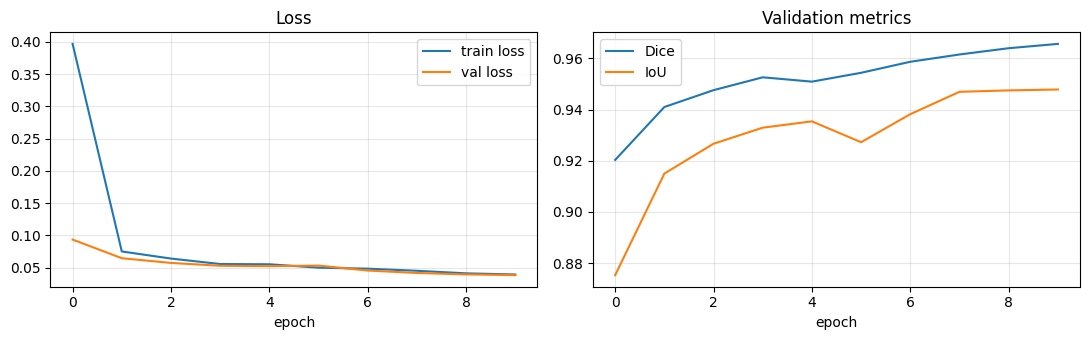

In [9]:
# Visualise training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(history['train_loss'], label='train loss')
ax[0].plot(history['val_loss'],   label='val loss')
ax[0].set_xlabel('epoch'); ax[0].set_title('Loss'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history['val_dice'], label='Dice')
ax[1].plot(history['val_iou'],  label='IoU')
ax[1].set_xlabel('epoch'); ax[1].set_title('Validation metrics'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Visualise predictions

Numbers are nice but pictures are better. Let's grab a few validation samples
and look at *input → ground-truth → predicted mask* side by side.

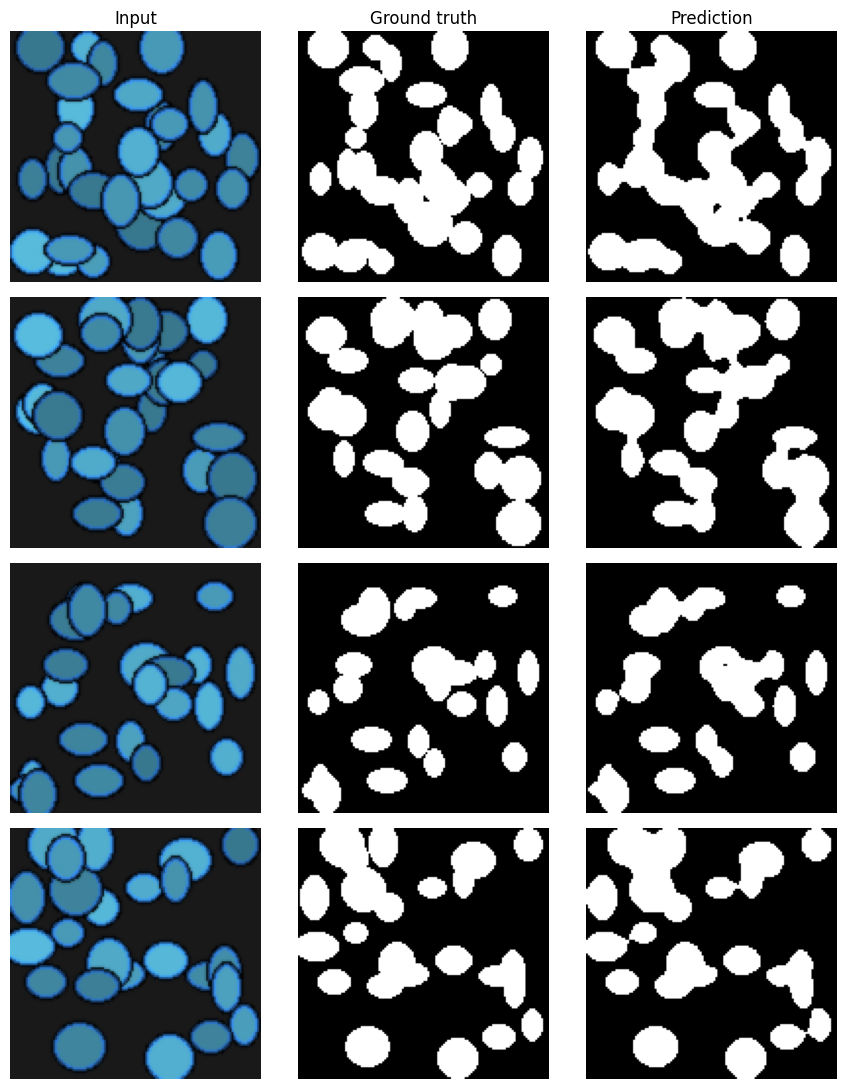

In [10]:
model.eval()
with torch.no_grad():
    xb, yb = next(iter(val_loader))
    logits = model(xb.to(DEVICE))
    prob   = torch.sigmoid(logits).cpu()
    pred   = (prob > 0.5).float()

fig, ax = plt.subplots(4, 3, figsize=(9, 11))
for i in range(4):
    ax[i, 0].imshow(xb[i].permute(1, 2, 0).numpy())
    ax[i, 1].imshow(yb[i, 0].numpy(),  cmap='gray')
    ax[i, 2].imshow(pred[i, 0].numpy(), cmap='gray')
    for a in ax[i]: a.axis('off')
ax[0, 0].set_title('Input');   ax[0, 1].set_title('Ground truth');  ax[0, 2].set_title('Prediction')
plt.tight_layout(); plt.show()

## 8. Instance segmentation with YOLOv8-seg

Time to switch gears. U-Net gave us a **single per-pixel class**. YOLOv8-seg gives us
**one mask per detected object** — that's the difference between *semantic* and *instance*
segmentation.

Ultralytics ships a pretrained model that runs in **one line**. We'll feed it a sample
image and visualise the masks.

In [11]:
# !pip install ultralytics -q  # if you haven't already
from ultralytics import YOLO

# nano-size pretrained instance-seg model (~6 MB)
seg_model = YOLO('yolov8n-seg.pt')
print(seg_model.info(verbose=False))

None


### Run inference on a sample image

We'll grab the canonical Ultralytics demo image (`bus.jpg`) — it ships inside the
package, so no download required.

In [12]:
# Use the demo image bundled with Ultralytics (no internet needed)
import ultralytics, glob
demo_paths = glob.glob(os.path.join(os.path.dirname(ultralytics.__file__), 'assets', '*.jpg'))
print('Bundled demo images:', [os.path.basename(p) for p in demo_paths])

img_path = demo_paths[0] if demo_paths else 'https://ultralytics.com/images/bus.jpg'
results  = seg_model(img_path, conf=0.4)
result   = results[0]

# results[0] has .boxes, .masks, .names
print(f'\nDetections: {len(result.boxes)}')
for box in result.boxes:
    cls_id = int(box.cls[0])
    conf   = float(box.conf[0])
    print(f'  {result.names[cls_id]:>10}  conf={conf:.2f}')

Bundled demo images: ['bus.jpg', 'zidane.jpg']

image 1/1 c:\Users\zebsh\miniconda3\envs\torch_env\Lib\site-packages\ultralytics\assets\bus.jpg: 640x480 4 persons, 1 bus, 123.1ms
Speed: 5.0ms preprocess, 123.1ms inference, 34.5ms postprocess per image at shape (1, 3, 640, 480)

Detections: 5
      person  conf=0.88
      person  conf=0.86
      person  conf=0.84
         bus  conf=0.84
      person  conf=0.41


### Plot the masks

`results[0].plot()` returns a BGR image with masks and boxes overlaid — ready for matplotlib.

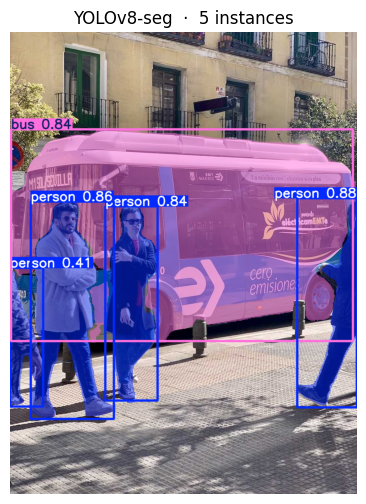

In [13]:
annotated_bgr = result.plot()              # H×W×3 BGR
annotated_rgb = annotated_bgr[:, :, ::-1]  # → RGB

plt.figure(figsize=(9, 6))
plt.imshow(annotated_rgb)
plt.axis('off')
plt.title(f'YOLOv8-seg  ·  {len(result.boxes)} instances')
plt.show()

### Peeking at the raw mask tensors

If you ever need the masks programmatically (e.g. to compute area, crop, or feed them
into another model), here's how to grab them.

masks tensor : (5, 640, 480)   dtype: uint8
classes       : ['person', 'person', 'person', 'bus', 'person']


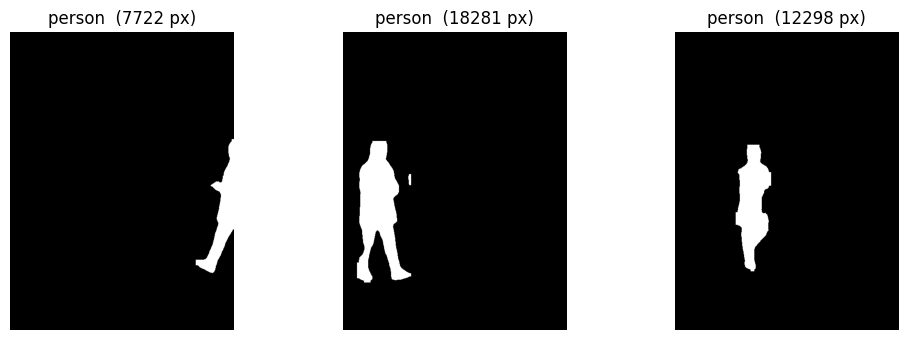

In [14]:
if result.masks is not None:
    masks = result.masks.data.cpu().numpy()       # (N, H, W) — binary masks
    cls   = result.boxes.cls.cpu().numpy().astype(int)
    names = [result.names[c] for c in cls]
    print('masks tensor :', masks.shape, '  dtype:', masks.dtype)
    print('classes       :', names)

    # Show the first 3 individual masks
    n_show = min(3, masks.shape[0])
    fig, ax = plt.subplots(1, n_show, figsize=(3.5 * n_show, 3.5))
    if n_show == 1: ax = [ax]
    for i in range(n_show):
        ax[i].imshow(masks[i], cmap='gray')
        ax[i].set_title(f'{names[i]}  ({masks[i].sum():.0f} px)')
        ax[i].axis('off')
    plt.tight_layout(); plt.show()
else:
    print('No masks returned — try a different image or lower the confidence.')

## 9. Summary

In this session we:

- Saw segmentation as **per-pixel classification** with input / mask / overlay
- Built a **synthetic cell-microscopy dataset** with on-the-fly augmentation
- Implemented a **TinyUNet** from scratch with encoder, bottleneck, decoder, and skip connections
- Trained with the standard **BCE + Dice combo loss** and tracked **Dice / IoU**
- Visualised input → ground-truth → prediction triplets
- Ran **YOLOv8-seg** for *instance* segmentation in a single line of code
- Extracted raw mask tensors for downstream use

### Next session

**Session 12 — Keypoint & Pose Estimation** with MediaPipe and YOLOv8-pose.

### Try it yourself

- Train for more epochs and see whether validation Dice keeps climbing
- Increase `base` (channel width) in `TinyUNet` and compare parameter count vs accuracy
- Swap the BCE+Dice loss for plain BCE and observe what changes when classes are imbalanced
- Run YOLOv8-seg on one of your own photos and inspect the masks